# Time Series Models

```{contents}
:local:
:depth: 2
```

:::{admonition} Learning Objectives
:class: tip

By the end of this chapter, you will be able to:
- Remove a linear trend and seasonal component from a time series using polynomial
  fitting and LASSO regression on sine-wave features.
- Construct an autoregressive (AR) model by casting lag features as a standard linear
  regression problem, and use BIC and PACF to select the model order $p$.
- Explain the difference between in-sample (one-step) and dynamic (multi-step) forecasts,
  and understand why dynamic forecasts degrade over time.
- Fit an ARIMA($p,d,q$) model using `statsmodels`, interpret the summary output, and
  generate forecasts with 95% confidence bands.
- Choose between AR, ARIMA, and seasonal ARIMA based on the ACF/PACF patterns and
  properties of the data, checking convergence and including a drift term when the
  data trend.
- Describe what a multivariate time series is, why it is harder to model than a
  univariate one, and where classical (VAR, state-space) and machine-learning (LSTM,
  probabilistic deep forecasters) approaches fit.
:::

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Lasso
import statsmodels.api as sm_api
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.style.use('../settings/plot_style.mplstyle')

clrs = np.array(['#003057', '#EAAA00', '#4B8B9B', '#B3A369', '#377117',
                 '#1879DB', '#8E8B76', '#F5D580', '#002233'])

In [2]:
# Reload and prepare the CO₂ dataset (same as Topic 6.1)
df_dow = pd.read_excel('data/impurity_dataset-training.xlsx')
dow_df = df_dow[['Date', 'y:Impurity']].copy()
dow_df['Date'] = pd.to_datetime(dow_df['Date'])
dow_df = dow_df.set_index('Date')

co2_raw = sm_api.datasets.co2.load_pandas().data
co2_df = co2_raw.copy()
co2_df['co2_interp'] = co2_df['co2'].interpolate(method='linear')
co2_df = co2_df[['co2', 'co2_interp']]

y = co2_df['co2_interp']
weeks = np.arange(len(y))
print(f'CO₂ series length: {len(y)} weeks')

CO₂ series length: 2284 weeks


## Removing Trends

Before reaching for specialized time-series machinery, notice that **de-trending is
just a regression problem**. We model the series as

$$x_t = f(t) + r_t$$

where $f(t)$ is a deterministic function of time and $r_t$ is what remains. Choosing
$f$ from a library of basis functions — polynomials here, sine waves in the next
section — and fitting it by least squares is *exactly* the general linear regression
of [Linear Regression](../1-numerical_methods/Topic1.3-Linear_Regression), with time
as the only input. The feature-library-plus-LASSO strategy below is likewise the same
regularized feature selection we used in
[Nonlinear Feature Engineering](../2-regression/Topic2.6-Nonlinear_Feature_Engineering):
nothing about the tooling is new, only the interpretation — the "features" are all
functions of $t$.

Our hand-rolled approach is a simple version of what the time-series literature calls
**harmonic regression** (fitting sinusoids at known or candidate frequencies).
Classical alternatives worth knowing: **classical decomposition** (estimate the trend
with a centered moving average, then average the de-trended values by season) and
**STL** (Seasonal-Trend decomposition using Loess; Cleveland et al., 1990), the modern
default in most statistical software — `statsmodels.tsa.seasonal.STL` implements it.
Chapter 3 of Hyndman & Athanasopoulos (see Additional Reading) covers these methods
well. We build the decomposition by hand here because it exposes the connection to
regression; in practice STL is a robust off-the-shelf choice.

### Linear Trend Fitting

Topic 6.1 showed that the CO₂ series is non-stationary, primarily because of a
rising long-term trend. A natural first step is to fit and subtract that trend.

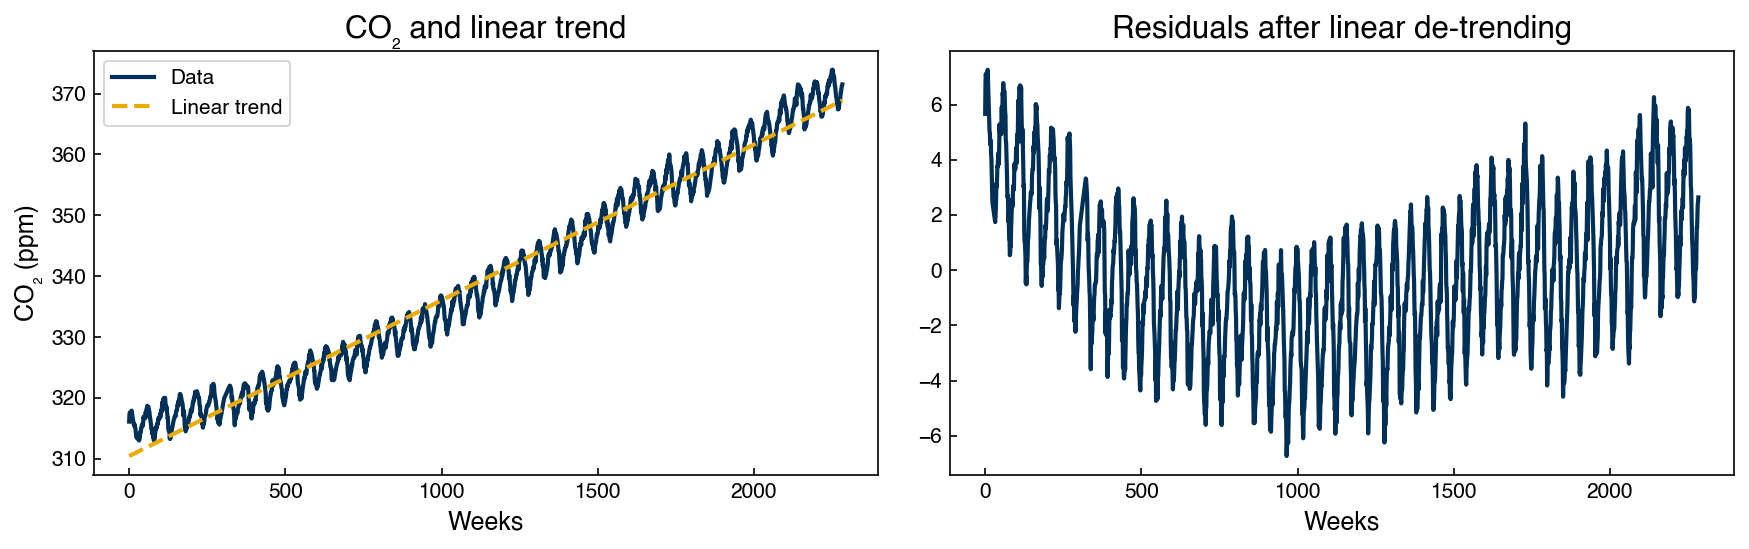

In [3]:
# Fit a linear trend to the full CO₂ series
m_lin, b_lin = np.polyfit(weeks, y, deg=1)
trend_linear = m_lin * weeks + b_lin
resid_linear = y.values - trend_linear

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(weeks, y.values, label='Data')
axes[0].plot(weeks, trend_linear, '--', label='Linear trend')
axes[0].set_title('CO₂ and linear trend')
axes[0].set_xlabel('Weeks')
axes[0].set_ylabel('CO₂ (ppm)')
axes[0].legend()

axes[1].plot(weeks, resid_linear)
axes[1].set_title('Residuals after linear de-trending')
axes[1].set_xlabel('Weeks')
plt.tight_layout()

The residuals after linear de-trending still show a clear oscillating pattern (annual
seasonality) and a slight upward curvature — suggesting the trend is not perfectly
linear. We address the seasonality next.

:::{exercise}
:label: ex-eda-ts-trend-fit

Compare polynomial trend models for the CO₂ series.

1. Fit a degree-1 (linear) and degree-2 (quadratic) polynomial trend to the full
   CO₂ series using `np.polyfit`.
2. Plot both trend lines on top of the data. Which fits the long-run trajectory
   better?
3. Compute the root-mean-square error (RMSE) between the data and each trend.
   Report both values. Does the improvement from degree-1 to degree-2 appear
   physically meaningful?
:::

## Removing Seasonality with LASSO

### Sine-Wave Feature Library

Seasonal patterns are periodic signals. We can model them by generating a library of
sine waves at candidate frequencies and offsets, then using LASSO to select the
combination that best fits the residuals:

$$y_t \approx ax + bx^2 + \sum_{k} c_k \sin\!\left(\frac{\pi x}{\nu_k} - \frac{\phi_k \pi}{\nu_k}\right)$$

where $\nu_k$ are candidate periods (in weeks) and $\phi_k$ are candidate phase offsets.

In [4]:
frequencies = [13, 23, 24, 25, 26, 26.5, 27]
offsets     = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]

def make_sine_features(x, frequencies, offsets):
    """Generate polynomial and sine-wave features from a 1-D time index."""
    feats  = [x, x**2]
    names  = ['x', 'x^2']
    for freq in frequencies:
        for offset in offsets:
            feats.append(np.sin((np.pi / freq) * x - (offset / freq) * np.pi))
            names.append(f'sin(π·x/{freq} + {offset})')
    return np.column_stack(feats), names

X_all, feat_names = make_sine_features(weeks, frequencies, offsets)
print(f'Feature matrix shape: {X_all.shape}')

Feature matrix shape: (2284, 100)


In [5]:
# Fit LASSO to select the most predictive sine-wave features
lasso_trend = Lasso(alpha=0.1, max_iter=5000)
lasso_trend.fit(X_all, y)
yhat_full = lasso_trend.predict(X_all)
model_resid = y.values - yhat_full

# Report selected features
selected = [(feat_names[i], lasso_trend.coef_[i]) for i in range(len(feat_names))
            if abs(lasso_trend.coef_[i]) > 0]
print(f'Selected {len(selected)} features:')
for name, coef in selected:
    print(f'  {name:45s}  {coef:+.4f}')

Selected 9 features:
  x                                              +0.0157
  x^2                                            +0.0000
  sin(π·x/13 + 8)                                +0.0825
  sin(π·x/13 + 9)                                +0.3651
  sin(π·x/26 + 0)                                +1.9242
  sin(π·x/26 + 13)                               -1.3976
  sin(π·x/26.5 + 0)                              -0.3621
  sin(π·x/26.5 + 13)                             +0.0043
  sin(π·x/27 + 4)                                -0.0130


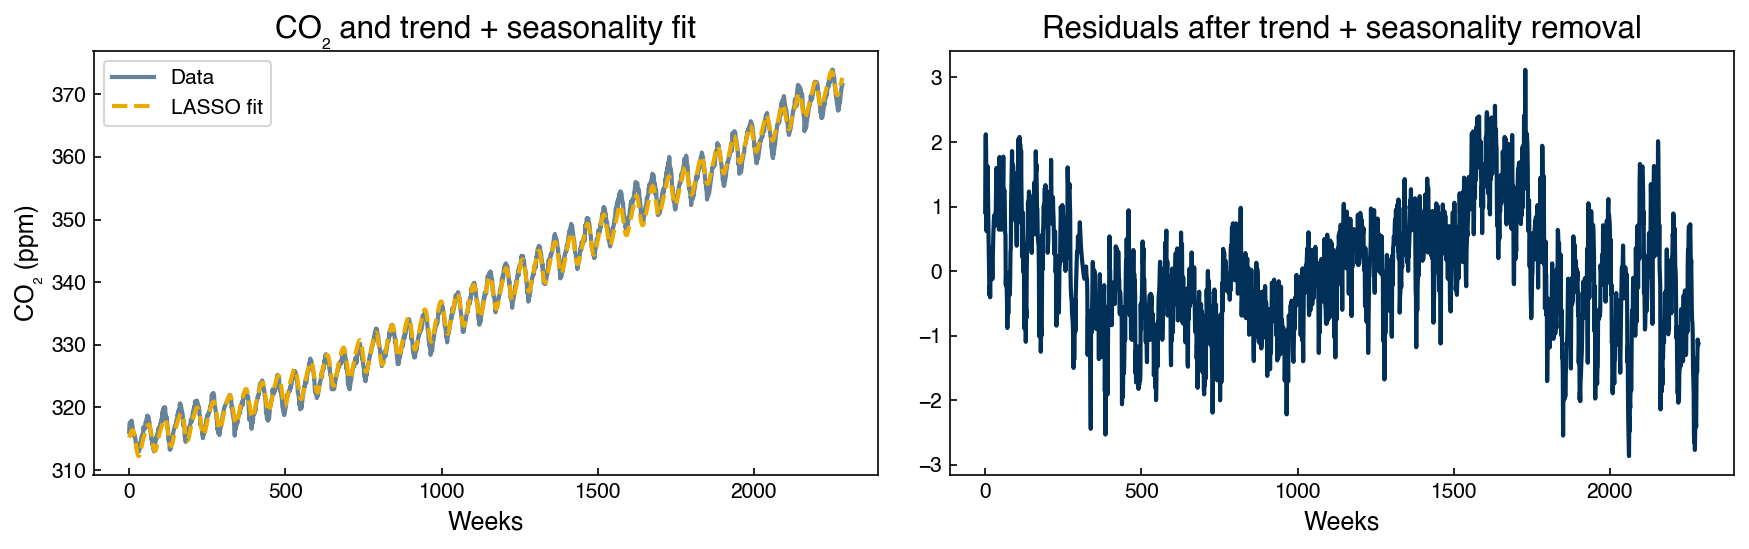

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(weeks, y.values, label='Data', alpha=0.6)
axes[0].plot(weeks, yhat_full, '--', label='LASSO fit')
axes[0].set_title('CO₂ and trend + seasonality fit')
axes[0].set_xlabel('Weeks')
axes[0].set_ylabel('CO₂ (ppm)')
axes[0].legend()

axes[1].plot(weeks, model_resid)
axes[1].set_title('Residuals after trend + seasonality removal')
axes[1].set_xlabel('Weeks')
plt.tight_layout()

In [7]:
# Verify stationarity of residuals
adf_resid = adfuller(model_resid)
print(f'Residuals ADF p-value: {adf_resid[1]:.4f}  →  P(stationary) ≈ {1 - adf_resid[1]:.4f}')

Residuals ADF p-value: 0.0004  →  P(stationary) ≈ 0.9996


The residuals are now stationary. However, the ACF still shows significant
autocorrelation at many lags — the trend and seasonality have been removed, but
short-term temporal dependence remains: when the residual is above zero this week, it
tends to still be above zero next week.

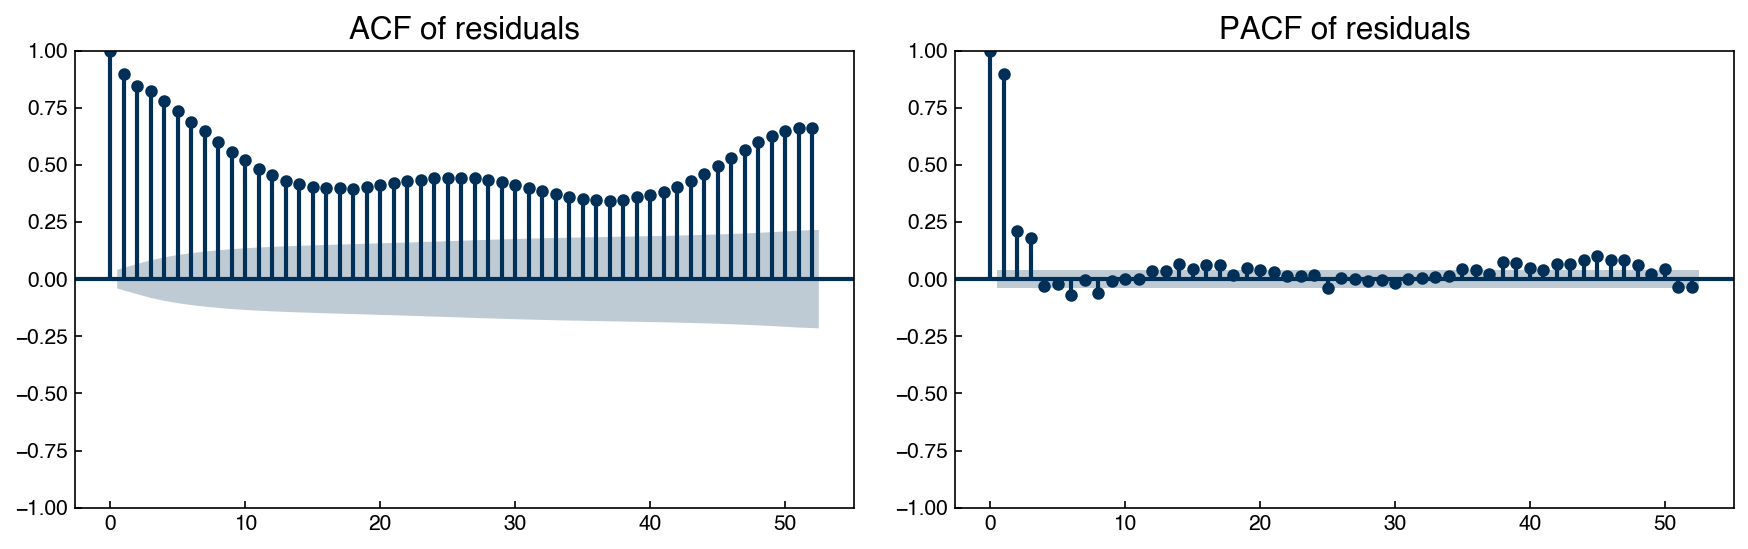

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf( model_resid, lags=52, ax=axes[0], title='ACF of residuals')
plot_pacf(model_resid, lags=52, ax=axes[1], title='PACF of residuals')
plt.tight_layout()

:::{exercise}
:label: ex-eda-ts-season-lasso

Tune the LASSO regularization for seasonal de-trending.

1. Sweep `alpha` over `[0.01, 0.05, 0.1, 0.5, 1.0]` for `Lasso(..., max_iter=5000)`
   fitted to `X_all` and `y`.
2. For each `alpha`, record the number of selected features (nonzero coefficients)
   and the ADF p-value of the residuals.
3. Plot the number of selected features vs. `alpha` and the ADF p-value vs. `alpha`
   on two subplots. Which `alpha` gives the fewest features while still producing
   stationary residuals (ADF p < 0.05)?
:::

### Differencing: Removing Correlation vs. Modeling It

Where does this persistence come from, and what can be done about it? Suppose each
residual is approximately its predecessor plus a small random shock:

$$r_t \approx r_{t-1} + \varepsilon_t$$

Then neighboring values are strongly correlated *by construction* — each one mostly
"inherits" the last. **Differencing** exploits the same structure in reverse: the
differences $\Delta r_t = r_t - r_{t-1} \approx \varepsilon_t$ recover just the
shocks, which are uncorrelated. That is why one round of differencing collapses the
slowly decaying ACF:

Differenced residuals ADF p-value: 1.9464e-29


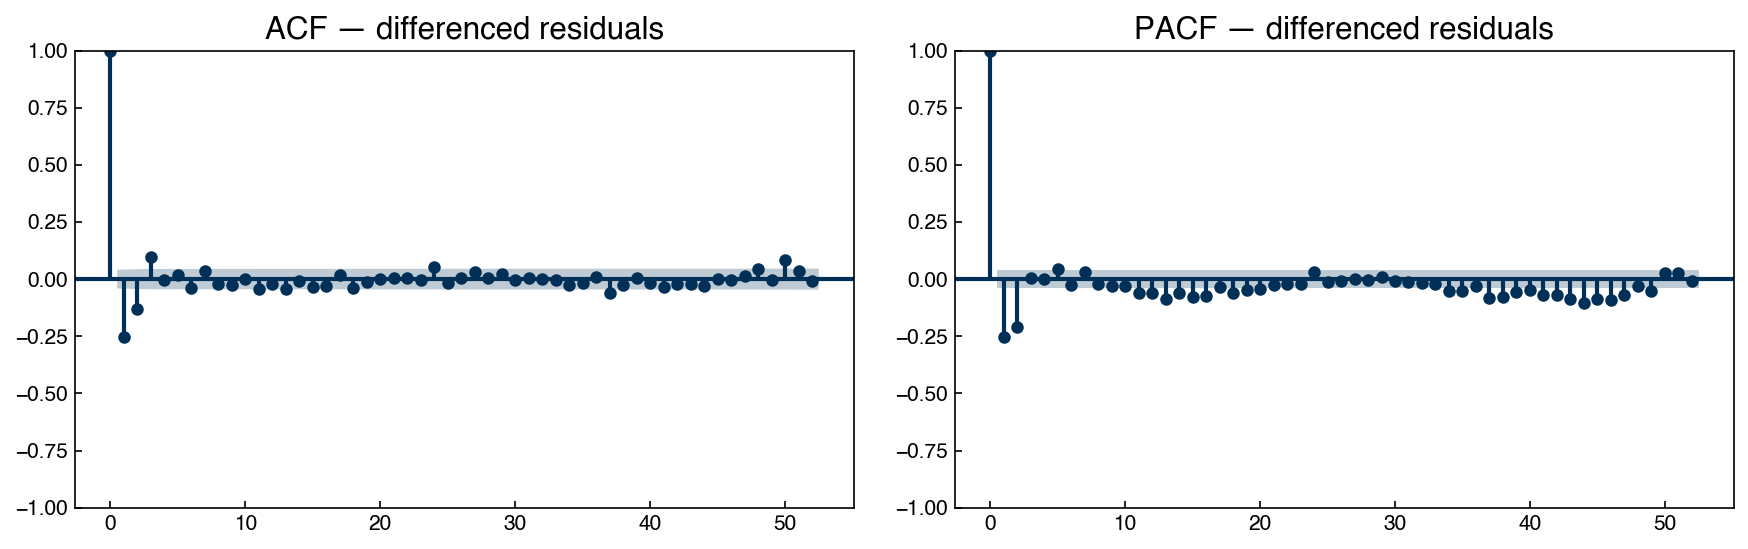

In [9]:
model_resid_s = pd.Series(model_resid, index=y.index)
resid_diff = (model_resid_s - model_resid_s.shift(1)).dropna()

adf2 = adfuller(resid_diff)
print(f'Differenced residuals ADF p-value: {adf2[1]:.4e}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf( resid_diff, lags=52, ax=axes[0], title='ACF — differenced residuals')
plot_pacf(resid_diff, lags=52, ax=axes[1], title='PACF — differenced residuals')
plt.tight_layout()

Differencing treats the autocorrelation as a *nuisance* and destroys it. But look at
what that means: the correlation between $r_t$ and $r_{t-1}$ is precisely the
statement that *the recent past predicts the present*. Destroying it throws away
forecastable structure. The alternative is to **model** the dependence instead —
write $r_t$ as an explicit function of its own recent values and fit the
coefficients. That is an autoregressive model, and it is the subject of the next
section. (Differencing returns in the ARIMA framework, where it plays its proper
role: removing *non-stationary* trends that autoregression alone cannot handle. Our
residuals are already stationary, so we model them directly — differencing an
already-stationary series is the "over-differencing" pitfall flagged in the Practical
Guidance below.)

---

## Auto-Regressive (AR) Models

### From ACF/PACF to Lag Features

An autoregressive model of order $p$ predicts $x_t$ from the $p$ most recent
observations:

$$x_t = b + \sum_{i=1}^{p} w_i x_{t-i} + \varepsilon_t$$

This is simply linear regression where the **features are lagged values of the target**.
We apply it to the stationary residuals from the LASSO de-trending — the series whose
ACF told us the recent past is informative — by stacking windows of length $p$ as the
feature matrix:

In [10]:
# Temporal train/test split — all "past" is training, "future" is test
train_ratio = 0.75
N_train = int(train_ratio * len(weeks))
N_test  = len(weeks) - N_train

past_weeks   = weeks[:N_train]
future_weeks = weeks[N_train:]
past_co2     = y.values[:N_train]
future_co2   = y.values[N_train:]

x_resid = model_resid   # stationary residuals after trend + seasonality removal

### BIC-Based Order Selection

We sweep $p$ from 1 to 20 and compute the Bayesian Information Criterion (BIC) for
each AR model fitted on the training portion. A lower BIC indicates a better
trade-off between fit quality and model complexity.

Best AR order by BIC: p = 3


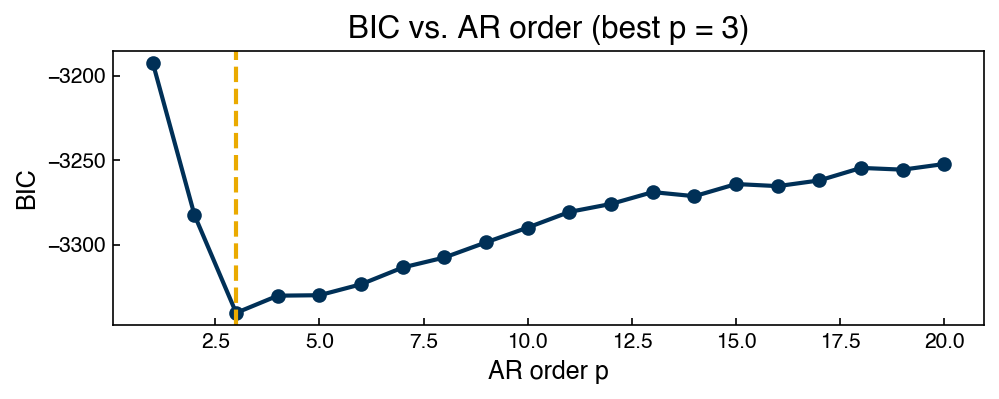

In [11]:
def BIC(y_true, y_pred, n_params):
    err = y_true - y_pred
    sigma = np.std(err)
    n = len(y_true)
    return n * np.log(sigma**2 + 1e-12) + n_params * np.log(n)

p_range = range(1, 21)
bic_list = []

for p in p_range:
    AR_X, AR_y = [], []
    for i in range(N_train):
        if i >= p:
            AR_X.append(x_resid[i-p:i])
            AR_y.append(x_resid[i])
    AR_X = np.array(AR_X)
    AR_y = np.array(AR_y)
    arm = LinearRegression().fit(AR_X, AR_y)
    bic_list.append(BIC(AR_y, arm.predict(AR_X), p))

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(list(p_range), bic_list, 'o-')
ax.set_xlabel('AR order p')
ax.set_ylabel('BIC')
ax.set_title('BIC vs. AR order')
best_p = list(p_range)[np.argmin(bic_list)]
ax.axvline(best_p, linestyle='--', color=clrs[1])
ax.set_title(f'BIC vs. AR order (best p = {best_p})')
plt.tight_layout()
print(f'Best AR order by BIC: p = {best_p}')

### Fitting the AR Model

Fitting the model is nothing more than ordinary least squares on the lag-feature
matrix. Each *row* of `AR_X` is a window of $p$ consecutive residuals, and the
corresponding entry of `AR_y` is the residual that immediately followed — so the
regression learns one set of weights $w_1, \ldots, w_p$ that best maps "the last $p$
values" to "the next value" across the entire training period. This is exactly the
regression machinery from Module 1; the only time-series ingredient is how the design
matrix was built.

In [12]:
p = best_p

AR_X, AR_y = [], []
for i in range(N_train):
    if i >= p:
        AR_X.append(x_resid[i-p:i])
        AR_y.append(x_resid[i])

AR_X = np.array(AR_X)
AR_y = np.array(AR_y)

ARM = LinearRegression().fit(AR_X, AR_y)
print(f'AR({p}) train r²: {ARM.score(AR_X, AR_y):.3f}')
print(f'Coefficients (oldest lag → most recent): {np.round(ARM.coef_, 3)}')
print(f'Intercept: {ARM.intercept_:.4f}')

AR(3) train r²: 0.816
Coefficients (oldest lag → most recent): [0.194 0.096 0.642]
Intercept: 0.0047


The fit explains roughly 80% of the residual variance — the autocorrelation that the
ACF revealed is genuinely predictive structure, and the AR model has captured it. The
coefficients are interpretable, too: the most recent lag carries the largest weight
(the best single predictor of this week's residual is last week's), with smaller
contributions from earlier lags. The intercept is nearly zero because the de-trended
residuals are centered.

### In-Sample (One-Step) Forecast

For the in-sample check, we feed **actual** past observations into the model at each
step — every prediction looks only one step ahead from real data. This is called a
"one-step-ahead" forecast. Because the model predicts the *residual*, the full
prediction adds the LASSO trend + seasonality back on top:

One-step error std:   0.374 ppm
Trend-only error std: 0.871 ppm


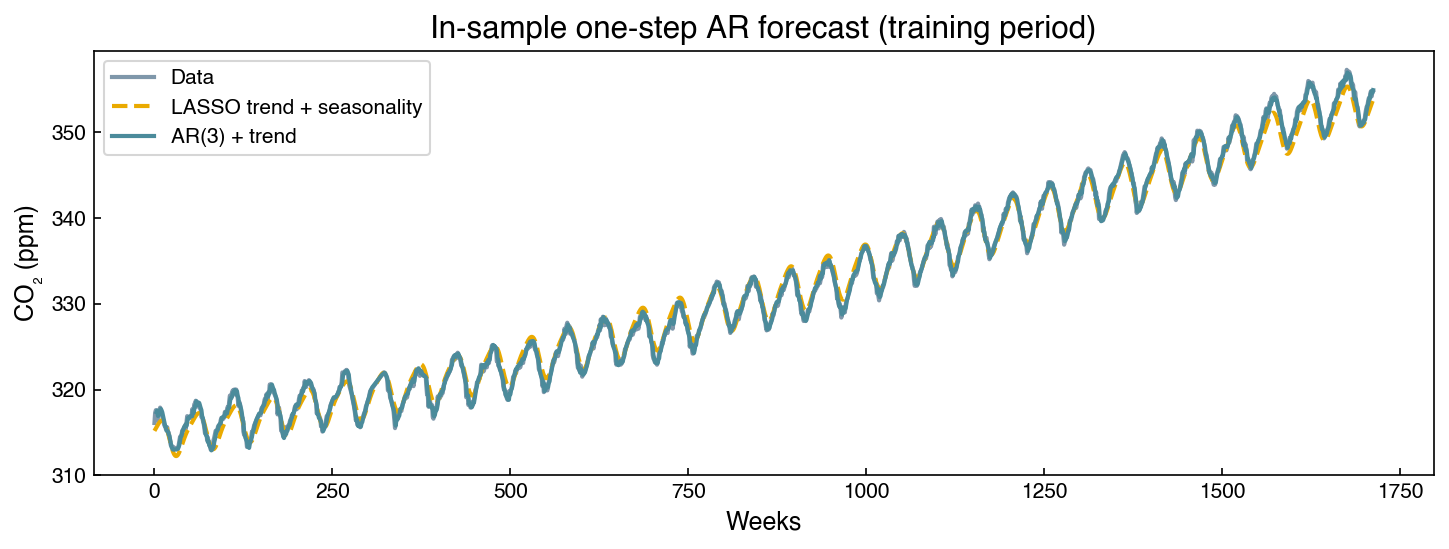

In [13]:
# Predict trend + seasonality for the training period
X_past, _ = make_sine_features(past_weeks, frequencies, offsets)
past_trend = lasso_trend.predict(X_past)

# One-step residual predictions (rows of AR_X hold ACTUAL lagged residuals)
one_step_resid = ARM.predict(AR_X)              # aligned with weeks p .. N_train-1
past_predict = past_trend[p:] + one_step_resid

err_ar    = past_co2[p:] - past_predict
err_trend = past_co2[p:] - past_trend[p:]
print(f'One-step error std:   {np.std(err_ar):.3f} ppm')
print(f'Trend-only error std: {np.std(err_trend):.3f} ppm')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(past_weeks, past_co2, label='Data', alpha=0.5)
ax.plot(past_weeks, past_trend, '--', label='LASSO trend + seasonality')
ax.plot(past_weeks[p:], past_predict, label=f'AR({p}) + trend')
ax.set_xlabel('Weeks')
ax.set_ylabel('CO₂ (ppm)')
ax.set_title('In-sample one-step AR forecast (training period)')
ax.legend()
plt.tight_layout()

The one-step forecast cuts the error standard deviation roughly in half relative to
the trend-only model, at every point in the training period. Keep the caveat in mind,
though: a one-step forecast is *shallow* — each prediction leans on the actual
measured values from the immediately preceding weeks, so it demonstrates that
short-range structure exists without demonstrating any long-range forecasting power.

:::{warning}
An easy mistake in this reconstruction is to predict *differences* and then cumulatively
sum them back into levels. Summing predicted increments lets every small bias
accumulate, so the reconstruction drifts away from the data like a random walk — the
resulting "forecast" can wander further from the series than the plain trend, even
in-sample. Model the stationary series directly (as here), or, if differencing is truly
needed for stationarity, anchor each step's reconstruction to the *measured* previous
value rather than the model's own running sum.
:::

### Dynamic (Multi-Step) Forecast

For the test period, we no longer have access to the actual future observations, so
each predicted residual must feed back as an input for the next step — a **dynamic
forecast**:

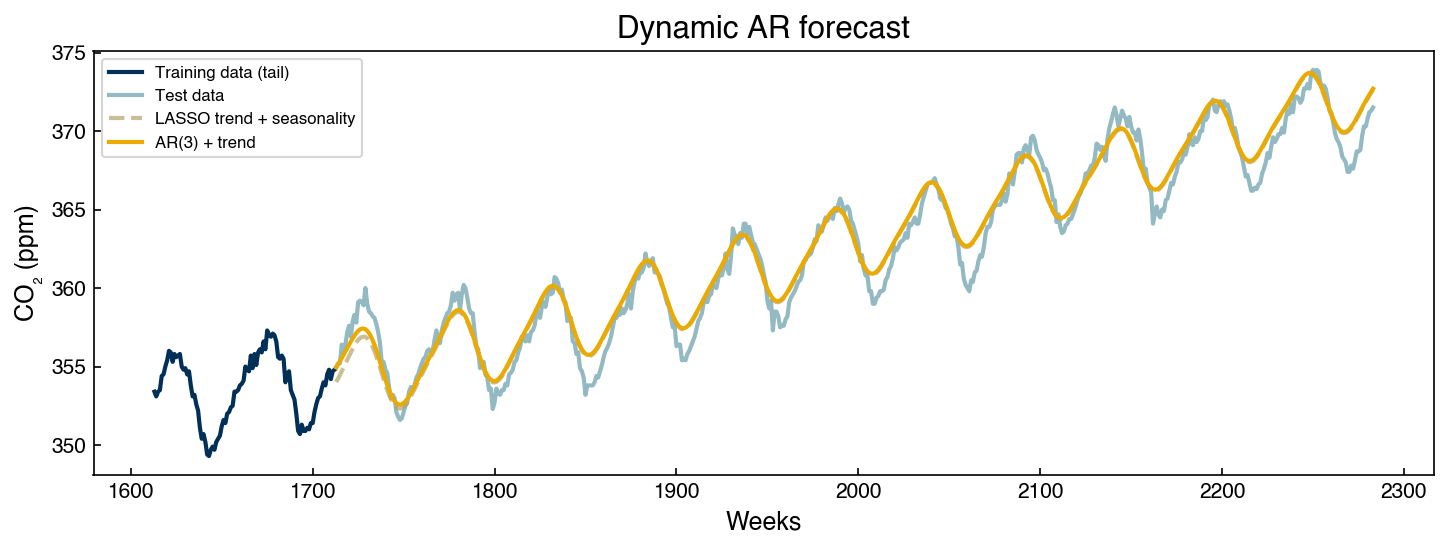

In [14]:
# Seed the dynamic forecast with the last p observed residuals
seed_x = list(x_resid[N_train-p:N_train])

AR_future = []
for i in range(N_test):
    new_X = np.array(seed_x[-p:]).reshape(1, -1)
    next_val = ARM.predict(new_X).item()
    AR_future.append(next_val)
    seed_x.append(next_val)

X_future, _ = make_sine_features(future_weeks, frequencies, offsets)
future_trend = lasso_trend.predict(X_future)
future_predict = future_trend + np.array(AR_future)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(past_weeks[-100:], past_co2[-100:], label='Training data (tail)', color=clrs[0])
ax.plot(future_weeks, future_co2, label='Test data', color=clrs[2], alpha=0.6)
ax.plot(future_weeks, future_trend, '--', alpha=0.7, color=clrs[3], label='LASSO trend + seasonality')
ax.plot(future_weeks, future_predict, color=clrs[1], label=f'AR({p}) + trend')
ax.set_xlabel('Weeks')
ax.set_ylabel('CO₂ (ppm)')
ax.set_title('Dynamic AR forecast')
ax.legend(fontsize=8)
plt.tight_layout()

Look closely at the start of the forecast: the AR component begins at the last
observed residual and *decays gradually toward zero* over the following months, so the
prediction starts offset from the bare trend and relaxes onto it. It does not collapse
instantly — the fitted lag weights sustain the influence of the last observations for
a meaningful horizon — but it cannot oscillate or regenerate structure indefinitely,
because it has no access to new measurements.

:::{note}
**Why does a dynamic forecast decay to the trend?** Iterating the fitted recursion
$\hat{r}_t = b + \sum_i w_i \hat{r}_{t-i}$ on its own outputs is a stable linear
system (the fitted weights of a stationary series correspond to roots inside the unit
circle), so each iteration shrinks the state geometrically toward the model's fixed
point — the mean of the residuals, i.e., zero. The rate of decay is set by the fitted
coefficients: strong short-lag correlation gives a slow decay (a long useful horizon),
weak correlation gives a fast one. Prediction errors also compound at each step, so
even before the forecast reaches the mean, its *reliability* has been shrinking. The
gap between one-step and dynamic performance is the honest measure of how much
genuine predictability the series contains.
:::

:::{exercise}
:label: ex-eda-ts-ar-order

Explore AR model order selection on the Dow impurity series.

1. Remove a linear trend from the Dow impurity series with `np.polyfit` and verify
   that the residuals are stationary with the ADF test.
2. Sweep AR orders $p \in \{1, 2, \ldots, 15\}$ on the training portion
   (first 75%) of the residual series. Compute and plot the BIC for each order.
3. Fit the best AR model (by BIC), and report the train $r^2$ and the coefficients.
   Is the most recent lag the dominant one, as it was for CO₂?
4. Compute and plot the one-step-ahead in-sample forecast for the training period,
   and compare its error standard deviation to the trend-only baseline.
:::

---

## ARIMA Models

### The ARIMA Framework

Manually de-trending, removing seasonality, differencing, and fitting an AR model is
instructive, but tedious. The **ARIMA($p, d, q$)** framework packages these steps
into a single model:

| Parameter | Meaning | How to choose |
|---|---|---|
| $p$ | AR order — lags in the autoregressive term | PACF of differenced series |
| $d$ | Integration order — number of differences needed for stationarity | ADF test (typically $d=1$ for most economic/physical series) |
| $q$ | MA order — lags in the moving-average (residual) term | ACF of differenced series |

The **moving-average (MA)** component uses past *forecast errors* rather than past
observations:

$$x_t = \mu + \varepsilon_t + \sum_{i=1}^{q} \theta_i \varepsilon_{t-i}$$

Combining AR($p$), integration ($d$), and MA($q$) gives ARIMA($p,d,q$), implemented
in `statsmodels.tsa.arima.model.ARIMA`.

### Choosing $(p, d, q)$

We already know $d = 1$ (one difference makes CO₂ stationary). To find $p$ and $q$,
inspect the ACF and PACF of the once-differenced series:

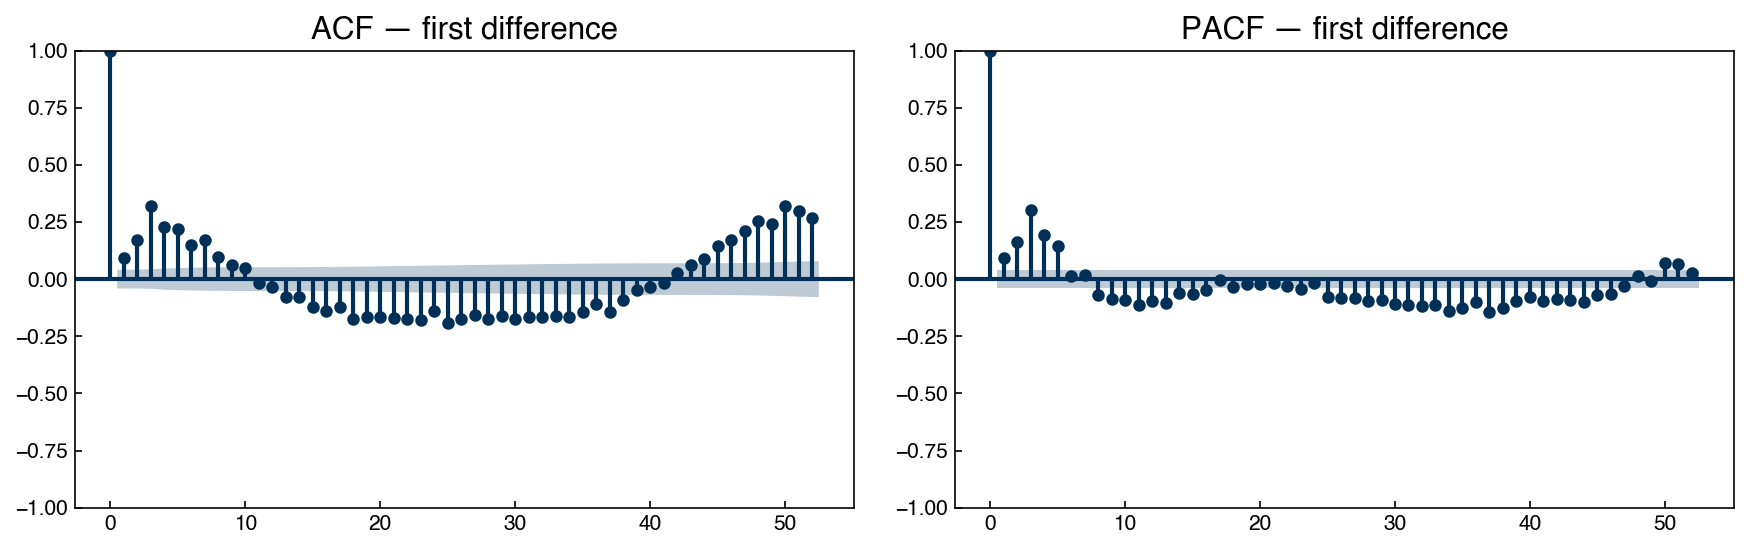

In [15]:
diffed = (co2_df['co2_interp'] - co2_df['co2_interp'].shift(1)).dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf( diffed, lags=52, ax=axes[0], title='ACF — first difference')
plot_pacf(diffed, lags=52, ax=axes[1], title='PACF — first difference')
plt.tight_layout()

- **PACF** cuts off sharply after lag 3–5 → $p \approx 4$
- **ACF** cuts off sharply after lag 3–4 → $q \approx 4$

These readings are starting points, not final answers. In practice ARIMA($4,1,4$) on
this series fails to converge: with four AR *and* four MA terms the model is
over-parameterized, and near-cancelling AR/MA roots leave the likelihood surface too
flat for the optimizer (statsmodels raises a `ConvergenceWarning`, and estimates from
a non-converged fit should not be trusted — the same lesson as checking
`result.success` in [Numerical Optimization](../1-numerical_methods/Topic1.4-Numerical_Optimization.md)).
Trimming the MA order to $q = 2$ resolves it. Two other settings matter:

- **Drift.** With $d \ge 1$, statsmodels excludes a constant term by default, so the
  forecast eventually levels off at the last value — clearly wrong for a series with a
  persistent upward trend. Passing `trend='t'` adds a linear-in-time term, which after
  one difference acts as a constant *drift*: the forecast keeps climbing at the
  average historical rate.
- **Convergence check.** Always confirm `mle_retvals['converged']` after fitting.

### Fitting ARIMA

In [16]:
from statsmodels.tsa.arima.model import ARIMA

# Temporal split
train_co2 = co2_df['co2_interp'].iloc[:N_train]
test_co2  = co2_df['co2_interp'].iloc[N_train:N_train + N_test]

arima = ARIMA(train_co2, order=(4, 1, 2), trend='t')
arima_fit = arima.fit()
print(f"Converged: {arima_fit.mle_retvals['converged']}")
print(arima_fit.summary())

Converged: True
                               SARIMAX Results                                
Dep. Variable:             co2_interp   No. Observations:                 1713
Model:                 ARIMA(4, 1, 2)   Log Likelihood                -953.605
Date:                Sat, 08 Aug 2026   AIC                           1923.209
Time:                        09:24:48   BIC                           1966.772
Sample:                    03-29-1958   HQIC                          1939.331
                         - 01-19-1991                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.0223      0.020      1.129      0.259      -0.016       0.061
ar.L1          1.5835      0.031     50.717      0.000       1.522       1.645
ar.L2         -0.5739      0.046    

In-sample mean absolute error: 0.323 ppm


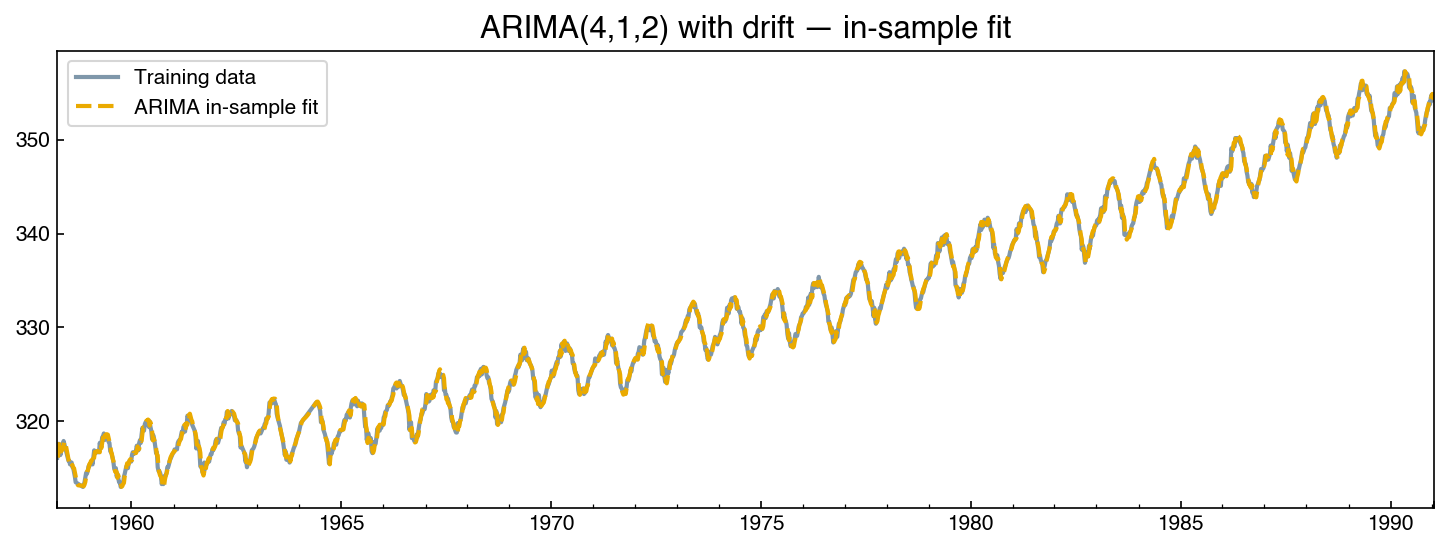

In [17]:
# In-sample fit. With d=1 there is no lagged value to difference at t=0, so the
# first "fitted value" is a meaningless placeholder — drop it before plotting.
fitted = arima_fit.fittedvalues.iloc[1:]

fig, ax = plt.subplots(figsize=(10, 4))
train_co2.plot(ax=ax, label='Training data', color=clrs[0], linewidth=2, alpha=0.5)
fitted.plot(ax=ax, label='ARIMA in-sample fit', color=clrs[1], linestyle='--')
ax.set_title('ARIMA(4,1,2) with drift — in-sample fit')
ax.legend()
plt.tight_layout()

mae_insample = np.mean(np.abs(arima_fit.resid.iloc[1:]))
print(f'In-sample mean absolute error: {mae_insample:.3f} ppm')

The fit hugs the data so closely that the two curves are nearly indistinguishable —
which is exactly what an in-sample, one-step-ahead fit on a strongly autocorrelated
series should look like (and, as with the AR model, says little about multi-step
forecasting skill).

### Dynamic Forecast with Uncertainty Bands

`get_forecast` produces the same kind of dynamic, multi-step forecast we built by hand
for the AR model: the model recursion is iterated forward with all future random
shocks set to their expected value of zero, so the predicted mean is what the fitted
dynamics *plus the drift term* propagate forward from the end of the training data.

Unlike our hand-rolled version, statsmodels also quantifies the forecast's
uncertainty. During fitting, maximum likelihood estimates the variance
$\hat{\sigma}^2$ of the one-step innovations $\varepsilon_t$ (visible as `sigma2` in
the summary table above). A forecast $h$ steps ahead has absorbed $h$ unrealized
shocks, each propagated through the model's dynamics, so its variance is the
accumulated sum of those contributions — it grows with the horizon, and for a
differenced ($d=1$) model it grows without bound, because the model is integrating a
random walk. The 95% bands are the forecast mean $\pm 1.96$ standard errors under the
assumption of Gaussian innovations. (Note what is — and is not — included: the bands
account for future randomness, but not for uncertainty in the fitted parameters
themselves, which we studied in
[Nonlinear Parameter Estimation](../1-numerical_methods/Topic1.5-Parameter_Estimation),
nor for the model being wrong. Real coverage is usually somewhat worse than nominal.)

Test MAE: 3.41 ppm;  fraction of test data inside 95% bands: 98.2%


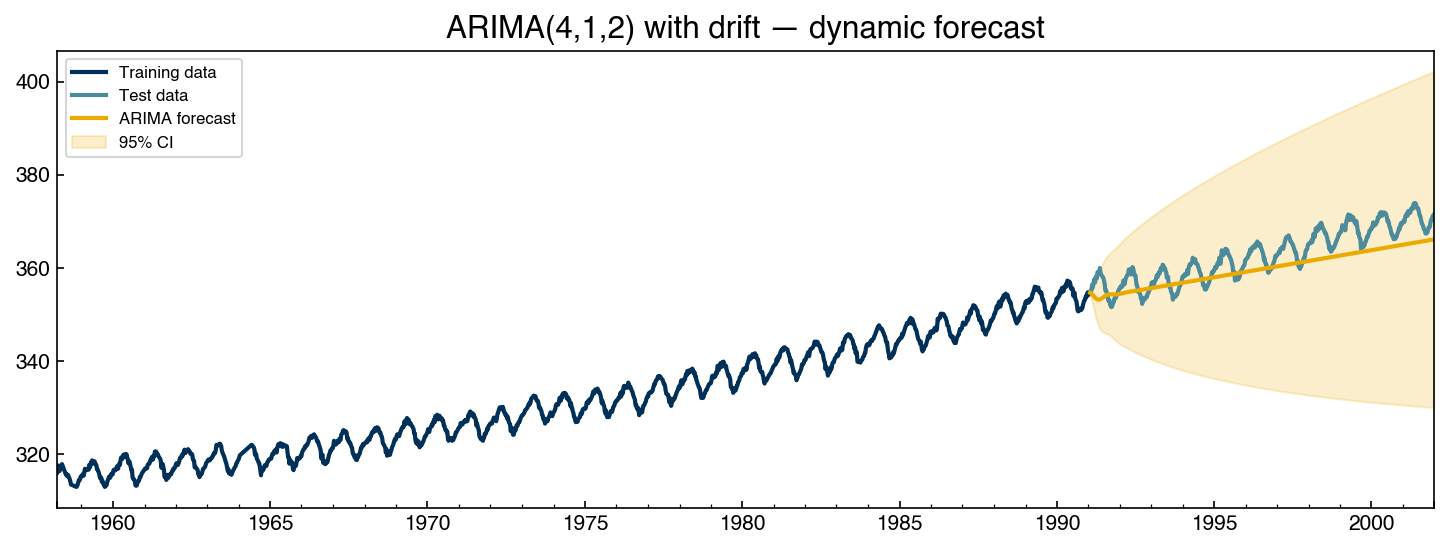

In [18]:
forecast_result = arima_fit.get_forecast(steps=N_test)
fc_mean = forecast_result.predicted_mean
fc_ci   = forecast_result.conf_int(alpha=0.05)   # 95% CI

fig, ax = plt.subplots(figsize=(10, 4))
train_co2.plot(ax=ax, label='Training data', color=clrs[0])
test_co2.plot(ax=ax, label='Test data', color=clrs[2])
fc_mean.plot(ax=ax, label='ARIMA forecast', color=clrs[1])
ax.fill_between(fc_ci.index,
                fc_ci.iloc[:, 0], fc_ci.iloc[:, 1],
                alpha=0.2, color=clrs[1], label='95% CI')
ax.set_title('ARIMA(4,1,2) with drift — dynamic forecast')
ax.legend(fontsize=8)
plt.tight_layout()

mae_test = np.mean(np.abs(fc_mean.values - test_co2.values))
inside = np.mean((test_co2.values >= fc_ci.iloc[:, 0].values) &
                 (test_co2.values <= fc_ci.iloc[:, 1].values))
print(f'Test MAE: {mae_test:.2f} ppm;  fraction of test data inside 95% bands: {inside:.1%}')

Thanks to the drift term, the forecast continues the long-run rise across the entire
test period (without it, the prediction would level off almost immediately at the last
training value). A brief transient from the AR terms is visible in the first few
weeks, but the annual oscillation fades quickly — a plain ARIMA model has no seasonal
terms, so it cannot regenerate the cycle. The 95% bands widen over the horizon exactly
as the theory above predicts, from under ±1 ppm at the first step to tens of ppm by
the end, and they comfortably contain the test data.

:::{note}
**Seasonal ARIMA (SARIMA)** extends the model to explicitly handle periodic
seasonality, adding seasonal AR and MA terms at a fixed period $s$ (e.g., $s=52$
for annual patterns in weekly data). The model is written SARIMA($p,d,q$)($P,D,Q$)$_s$.
For the CO₂ dataset, a SARIMA model with $s=52$ would preserve the annual oscillation
throughout the forecast horizon. This is beyond the scope of this course, but the
statsmodels `SARIMAX` class implements it directly.
:::

:::{exercise}
:label: ex-eda-ts-arima-dow

Apply an ARIMA model to the Dow impurity series.

1. Use the Augmented Dickey-Fuller test to determine $d$ (the number of differences
   needed for stationarity).
2. Inspect the ACF and PACF of the differenced series to estimate $p$ and $q$.
3. Fit `ARIMA(p, d, q)` on the first 75% of the Dow data (chronological split).
4. Generate a dynamic forecast for the remaining 25%. Plot the forecast with 95%
   confidence bands overlaid on the actual test data.
5. Report the mean absolute error (MAE) on the test set. How does it compare to
   just using the training mean as the forecast?
:::

---

## Practical Guidance

The table below summarizes the main modeling choices for univariate time series:

| Situation | Recommended approach |
|---|---|
| Clear linear trend, strong seasonal pattern, abundant data | SARIMA or Prophet (beyond scope) |
| Clear trend, moderate autocorrelation after differencing | ARIMA |
| Stationary after 1 difference, PACF cuts off sharply | AR($p$) with manual lag features |
| No obvious trend, low autocorrelation | Standard regression ignoring time order may suffice |
| Non-stationary, complex multi-frequency seasonality | Remove trend/seasonality with LASSO features, then AR or ARIMA on residuals |

**Common pitfalls:**
- Using $r^2$ on a non-stationary series is misleading — a model that just predicts
  the trend achieves high $r^2$ without capturing any dynamics.
- Forgetting to respect chronological order in train/test splits leads to data leakage.
- Over-differencing (applying more differences than necessary) destroys useful signal.
- Dynamic forecasts always degrade — report confidence intervals rather than treating
  long-range forecasts as reliable point estimates.

:::{exercise}
:label: ex-eda-ts-model-select

Use the practical guidance table to choose and evaluate a model for a new scenario.

Given the Dow impurity series:

1. Check whether the original (undifferenced) series is stationary using the ADF
   test. Based on the result and the ACF/PACF patterns, select a row from the
   guidance table above and state which model you would recommend.
2. Implement your recommended model and generate a dynamic forecast for the last
   25% of the series (chronological split). Plot the forecast with 95% confidence
   bands if applicable.
3. Compute the mean absolute error (MAE) of the forecast and compare it to the
   naive baseline (predicting the training-set mean for all future values).
:::

---

## Multivariate Time Series and Advanced Models

Everything in this chapter has been **univariate**: one variable, predicted from its
own history. But recall where the Dow impurity column came from — a dataset with more
than forty simultaneously recorded process variables (flows, temperatures, pressures,
steam duties). That full dataset is a **multivariate time series**: a *vector* of
measurements at every time step,

$$\mathbf{x}_t = (x_t^{(1)}, x_t^{(2)}, \ldots, x_t^{(k)}),$$

in which each variable may depend not only on its own past but on the past of every
other variable. That cross-coupling is the whole point — an upstream flow disturbance
shows up in a downstream temperature some minutes later, and exploiting such lead–lag
relationships is how a model can see disturbances coming. It is also what makes the
problem genuinely hard:

- **Parameter explosion.** The natural generalization of AR($p$) is the vector
  autoregression **VAR($p$)**, in which each of the $k$ variables gets $p$ lag
  coefficients for *every* variable: $k^2 p$ parameters. For the Dow data with
  $k = 40$ and $p = 5$, that is 8,000 coefficients — demanding enormous data and
  inviting overfitting.
- **Heterogeneity.** The channels have different units, scales, noise levels, and
  sometimes different sampling rates or missing-data patterns, so the preprocessing
  choices from Topic 6.1 must be made per channel — consistently.
- **Correlation is not causation.** Two sensors may move together because one drives
  the other or because both respond to a third variable; a model can exploit the
  correlation either way, but *interpreting* it requires care (the econometrics
  literature formalizes one useful notion as *Granger causality*: does adding
  variable $j$'s history improve forecasts of variable $i$ beyond $i$'s own history?).

Classical tools exist — statsmodels implements VAR and its exogenous-input extension
VARMAX, and **state-space models with Kalman filtering** have deep roots in process
control — but the parameter-explosion problem is one reason **machine learning methods
dominate modern multivariate forecasting**. Neural networks share structure across
channels instead of estimating every cross-coefficient independently: recurrent
architectures like the **LSTM** (Hochreiter & Schmidhuber, 1997) carry a learned
hidden state through time, and we build one for exactly this kind of data in
[Neural Network Architectures](Topic6.4-Neural_Network_Architectures); Amazon's
**DeepAR** (Salinas et al., 2020) trains a single recurrent model across thousands of
related series and outputs full probabilistic forecasts; and attention-based
(transformer) forecasters are an active research frontier — see Lim & Zohren (2021)
for an accessible survey of the deep-learning forecasting landscape. In chemical
engineering practice, the same machinery appears as **soft sensors**: models that
predict a hard-to-measure quality variable (like our impurity) from the many
easy-to-measure process variables around it — which is precisely the multivariate
generalization of what this chapter has been doing with one column.

:::{exercise}
:label: ex-eda-ts-multivar

Get a first taste of cross-variable structure in the full Dow dataset.

1. Load the full impurity dataset and select `y:Impurity` plus two upstream process
   variables of your choice (e.g., `x1:Primary Column Reflux Flow` and
   `x7:Primary Column Head Pressure`).
2. For each process variable, compute the Pearson correlation between the variable
   *lagged by $k$ hours* and the impurity, for $k \in \{0, 1, \ldots, 24\}$. Plot
   correlation vs. lag for both variables.
3. Does either variable correlate more strongly with *future* impurity than with
   simultaneous impurity? What would such a lead–lag relationship mean physically,
   and how could a soft sensor exploit it?
:::

---

## Summary

- Removing **trend and seasonality** (via polynomial + LASSO sine-wave fitting) isolates
  the residual stochastic component that is the target for AR/ARIMA modeling.

- **AR($p$) models** cast time series prediction as standard linear regression on lag
  features. The order $p$ is selected using the PACF or BIC sweep.

- **In-sample (one-step) forecasts** use actual past observations as inputs and look
  excellent; **dynamic (multi-step) forecasts** feed back predictions and degrade
  quickly as errors accumulate — this gap is a key diagnostic of how much genuine
  predictability exists beyond the trend.

- **ARIMA($p,d,q$)** packages differencing ($d$), autoregression ($p$), and
  moving-average error terms ($q$) into a single framework. The parameters are chosen
  from PACF (→ $p$), ADF test (→ $d$), and ACF (→ $q$) — then adjusted for practical
  behavior: check that the MLE converged (over-parameterized ARMA terms often prevent
  it), and include a drift term (`trend='t'`) so forecasts of trending data continue
  the trend. Forecast bands come from the estimated innovation variance accumulated
  over the horizon; they cover future randomness, not parameter or model error.

- For seasonal data like CO₂, **SARIMA** extends ARIMA with seasonal terms; for
  purely trend-plus-noise industrial data like Dow impurity, standard ARIMA or AR
  models are usually sufficient.

- **Multivariate time series** (vectors of coupled measurements, like the full Dow
  process dataset) offer lead–lag information across variables at the cost of a
  parameter explosion (VAR needs $k^2 p$ coefficients). Neural approaches (LSTM,
  DeepAR) share structure across channels and dominate modern practice; in ChE this
  appears as soft sensors.

## Additional Reading

- Hyndman & Athanasopoulos, *Forecasting: Principles and Practice* (3rd ed.) —
  Chapter 3 covers decomposition and de-trending (classical decomposition, STL);
  Chapters 8–9 cover ARIMA and SARIMA in depth. R examples, but most concepts
  transfer directly to Python/statsmodels: [otexts.com/fpp3](https://otexts.com/fpp3/)
- Cleveland, R. B., Cleveland, W. S., McRae, J. E., & Terpenning, I. (1990),
  "STL: A seasonal-trend decomposition procedure based on Loess,"
  *Journal of Official Statistics* 6(1), 3–73 — the classic de-trending/decomposition
  method (`statsmodels.tsa.seasonal.STL`)
- Box, G. E. P., Jenkins, G. M., Reinsel, G. C., & Ljung, G. M. (2015),
  *Time Series Analysis: Forecasting and Control* (5th ed., Wiley) — the foundational
  reference for ARIMA ("Box–Jenkins") modeling
- Lim, B. & Zohren, S. (2021), "Time-series forecasting with deep learning: a survey,"
  *Phil. Trans. R. Soc. A* 379: 20200209 — accessible overview of neural forecasting
  (RNN/LSTM, attention, hybrid methods)
- Salinas, D., Flunkert, V., Gasthaus, J., & Januschowski, T. (2020), "DeepAR:
  Probabilistic forecasting with autoregressive recurrent networks,"
  *International Journal of Forecasting* 36(3), 1181–1191
- statsmodels documentation:
  [ARIMA](https://www.statsmodels.org/stable/generated/statsmodels.tsa.arima.model.ARIMA.html),
  [SARIMAX](https://www.statsmodels.org/stable/generated/statsmodels.tsa.statespace.sarimax.SARIMAX.html),
  [VAR](https://www.statsmodels.org/stable/vector_ar.html)
- Seabold, S. & Perktold, J. (2010), "statsmodels: Econometric and statistical
  modeling with Python," *Proceedings of the 9th Python in Science Conference*